In [284]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [285]:
import os 
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from statsmodels.stats.diagnostic import het_arch

In [286]:
from proj.features import transforms
from proj.data.storage import LocalStorage
from proj.evaluation.backtester import Backtester
from proj.evaluation.engine import greedy_forward_feature_selection, greedy_hyperparam_tuning, model_selection, evaluate_models
from proj.utils.paths import find_project_root, build_paths
from proj.data.merge_helpers import *


In [287]:
repo_root = find_project_root()
paths = build_paths(repo_root)

In [288]:
style_path = os.path.join(paths['SRC'], 'proj', 'utils', 'styler.mplstyle')
plt.style.use(style_path)

In [289]:
storage = LocalStorage(base_dir=Path("../data"))


In [290]:
oos = storage.read_parquet("external/oos_predictions.parquet")
oos['oos'] = True
max_oos = oos.index.max()

In [291]:
gold = storage.read_parquet("gold/modeling_table.parquet")
gold = gold[['ret_xle', 'rv_xle']].loc[:max_oos]
# gold['ret_xle'] = gold['ret_xle'] / 100

In [292]:
df = gold.merge(oos,how="left", left_index=True, right_index=True)

In [293]:
df.head()

,ret_xle,rv_xle,truth,"EWMA(rv, λ=0.94)","GARCH(1,1)","GARCHProxyX(1,1,t,X=3)",HAR-RV,HAR-RV-X(3),XLE,oos
timestamp,,,,,,,,,,
2021-01-06 21:00:00+00:00,-0.353565,1.069716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07 21:00:00+00:00,0.466745,2.526196,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-08 21:00:00+00:00,-1.100503,3.264573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-11 21:00:00+00:00,2.614148,2.235152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-12 21:00:00+00:00,2.297663,3.475628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [294]:
df[df['oos'].isna()][['rv_xle', 'ret_xle']].corr()

,rv_xle,ret_xle
rv_xle,1.000000,-0.163705
ret_xle,-0.163705,1.000000


In [295]:
for_trading = df[df['oos']== True]

In [296]:
for_trading.head()

,ret_xle,rv_xle,truth,"EWMA(rv, λ=0.94)","GARCH(1,1)","GARCHProxyX(1,1,t,X=3)",HAR-RV,HAR-RV-X(3),XLE,oos
timestamp,,,,,,,,,,
2025-01-14 21:00:00+00:00,1.001602,1.015373,1.015373,1.105876,0.897145,0.955379,1.199641,1.257126,44.135769,True
2025-01-15 21:00:00+00:00,1.394535,1.254940,1.254940,1.100445,0.901654,0.983567,1.086795,1.246676,44.788948,True
2025-01-16 21:00:00+00:00,0.310904,0.504204,0.504204,1.109715,0.929437,1.220608,1.169641,1.496860,45.113117,True
2025-01-17 21:00:00+00:00,0.176134,0.259360,0.259360,1.073384,0.910312,0.678088,0.879542,0.884619,45.461483,True
2025-01-21 21:00:00+00:00,0.154987,0.520784,0.520784,1.024543,0.889930,0.472048,0.619556,0.570331,45.229240,True


### Volatility Targeting

In [297]:

def vol_target_all_pct(
    ret_pct: pd.Series,          # daily returns in % (2.24 means 2.24%)
    var_pct2_daily: pd.Series,   # daily variance in %^2
    target_ann_vol_pct: float = 14.0,  # annual target vol in %
    ann_factor: int = 252,
    w_min: float = 0.0,
    w_max: float = 6.0,
    eps: float = 1e-12,
    power: float = 1.0,
    lag: int = 1,                # 1 = safest default to avoid lookahead
    ret_scale: str = "pct",      # "pct" (2.24=2.24%) or "bps" (2.24=2.24 bps)
) -> pd.DataFrame:
    """
    Vol targeting in a percent-unit system:
      - ret is in percent
      - variance forecasts are in percent^2 per day

    Returns:
      w: exposure/leverage
      ret: strategy daily return in percent
      equity: cumulative equity (starts at 1)
    """

    r = ret_pct.astype(float).copy()

    # Guard against the common confusion: bps vs %
    if ret_scale == "bps":
        r = r / 100.0   # 2.24 bps -> 0.0224% (still percent units)
    elif ret_scale != "pct":
        raise ValueError("ret_scale must be 'pct' or 'bps'")

    v_hat = var_pct2_daily.astype(float)

    # Annualized volatility forecast in percent:
    # daily sigma (%) = sqrt(v), annual sigma (%) = sqrt(v) * sqrt(ann_factor)
    sig_ann_pct = np.sqrt(v_hat.clip(lower=0.0) + eps) * np.sqrt(float(ann_factor))

    # Exposure / leverage
    w = (target_ann_vol_pct / sig_ann_pct) ** power
    w = w.clip(lower=w_min, upper=w_max)

    # Apply with lag to avoid lookahead when forecasts are computed at/after close
    strat_ret_pct = (w.shift(lag) * r).fillna(0.0)/ 100 

    # Compound: percent -> decimal by dividing by 100 exactly once
    equity = (1.0 + strat_ret_pct).cumprod()

    return pd.DataFrame({"w": w, "ret": strat_ret_pct, "equity": equity})


In [298]:
historical_mean_rv = np.sqrt(df[df['oos'].isna()]['rv_xle'])
historical_mean_rv_annual = historical_mean_rv * np.sqrt(252) 
historical_mean_rv_annual.describe()

count    1010.000000
mean       19.349733
std         8.698437
min         4.951242
25%        13.329684
50%        17.469787
75%        22.938871
max        88.230758
Name: rv_xle, dtype: float64

In [299]:
historical_mean_rv_annual = 7

In [300]:
vol_cols = [
    "EWMA(rv, λ=0.94)",
    "GARCH(1,1)",
    "GARCHProxyX(1,1,t,X=3)",
    "HAR-RV",
    "HAR-RV-X(3)",
]

vol_cols = [
    # "rv_xle",
    "GARCHProxyX(1,1,t,X=3)",
    "HAR-RV-X(3)",

]

results = {}

for col in vol_cols:
    results[col] = vol_target_all_pct(
        ret_pct=for_trading["ret_xle"],
        var_pct2_daily=for_trading[col],
        target_ann_vol_pct= float(historical_mean_rv_annual),
    )


In [301]:

def performance_stats(
    strat_ret: pd.Series,   # daily arithmetic returns in DECIMALS
    ann_factor: int = 252,
):
    r = strat_ret.dropna().astype(float)
    if r.empty:
        return pd.Series(dtype=float)

    # ----- equity curve -----
    equity = (1.0 + r).cumprod()
    T = len(r)

    # ----- geometric annualized return -----
    ann_ret = equity.iloc[-1] ** (ann_factor / T) - 1.0

    # ----- robust volatility (percentile-based) -----
    p16, p84 = np.percentile(r, [16, 84])
    vol_d = (p84 - p16) / 2.0
    ann_vol = vol_d * np.sqrt(ann_factor)

    # ----- robust Sharpe-like ratio -----
    sharpe_robust = ann_ret / ann_vol if ann_vol > 0 else np.nan

    # ----- max drawdown -----
    max_dd = (equity / equity.cummax()).min() - 1.0

    return pd.Series({
        "ann_return": ann_ret,
        "ann_vol": ann_vol,
        "sharpe": sharpe_robust,
        "max_drawdown": max_dd,
        "n_days": T,
        # "p50_daily": np.percentile(r, 50),
        # "p5_daily": np.percentile(r, 5),
        # "p95_daily": np.percentile(r, 95),
    })


In [302]:
xle_ret = for_trading["ret_xle"] / 100

xle_equity = (1 + xle_ret.fillna(0)).cumprod()

comparison = {}

# Buy-and-hold
comparison["XLE Buy & Hold"] = performance_stats(xle_ret)

# Vol-targeted strategies
for model, res in results.items():
    comparison[f"VT – {model}"] = performance_stats(res["ret"])

perf_compare = pd.DataFrame(comparison).T
perf_compare


,ann_return,ann_vol,sharpe,max_drawdown,n_days
XLE Buy & Hold,0.043748,0.157188,0.278317,-0.104382,252.0
"VT – GARCHProxyX(1,1,t,X=3)",0.010663,0.069367,0.153725,-0.051047,252.0
VT – HAR-RV-X(3),0.015800,0.070238,0.224949,-0.048584,252.0


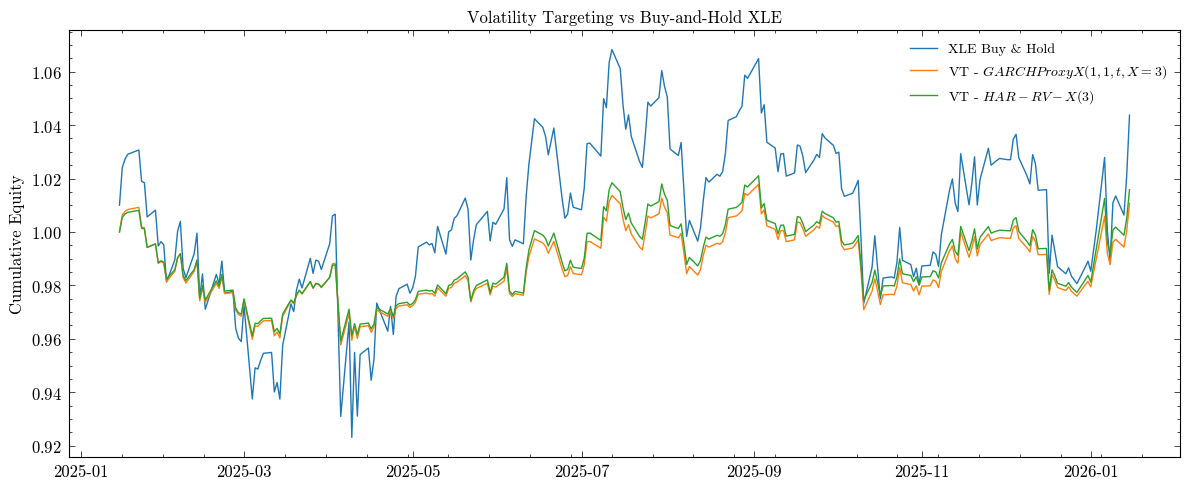

In [303]:

plt.figure(figsize=(12, 5))

plt.plot(xle_equity, label="XLE Buy & Hold")

for model, res in results.items():
    plt.plot(res["equity"], label=f"VT - ${model}$")

plt.legend()
plt.title("Volatility Targeting vs Buy-and-Hold XLE")
plt.ylabel("Cumulative Equity")
plt.tight_layout()
plt.show()
